In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## DATASET FEATURES

##### 1.Gender
##### 2.Race/ethnicity
##### 3.Parental level of education
##### 4.Lunch
##### 5.Test preparation course
##### 6.Math Score
##### 7.Reading Score
##### 8.Writing score

In [59]:
df = pd.read_csv('data/studs.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [61]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

#### No Null values in the dataset

In [62]:
df.duplicated().sum()

np.int64(0)

#### No Duplicated values in the dataset

In [63]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [64]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insights

from the above table we can infer 3 things:

1. The mean values of all the 3 numerical columns are close to each other ( 66-69 )
2. The standard deviation is also close ( 14-15 )
3. The minimum value for math score is 0 while for the rest 2 is 10 and 17

## FEATURE EXTRACTION

In [65]:
num_features = [col for col in df.columns if df[col].dtype == 'int64' or df[col].dtype == 'float64']
cat_features = [col for col in df.columns if col not in num_features]
print(num_features)
print(cat_features)

['math score', 'reading score', 'writing score']
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [66]:
df['total_score'] = df['reading score'] + df['writing score'] + df['math score']
df['average_score'] = df['total_score']/3
df.head()

num_features = [col for col in df.columns if df[col].dtype == 'int64' or df[col].dtype == 'float64']
cat_features = [col for col in df.columns if col not in num_features]

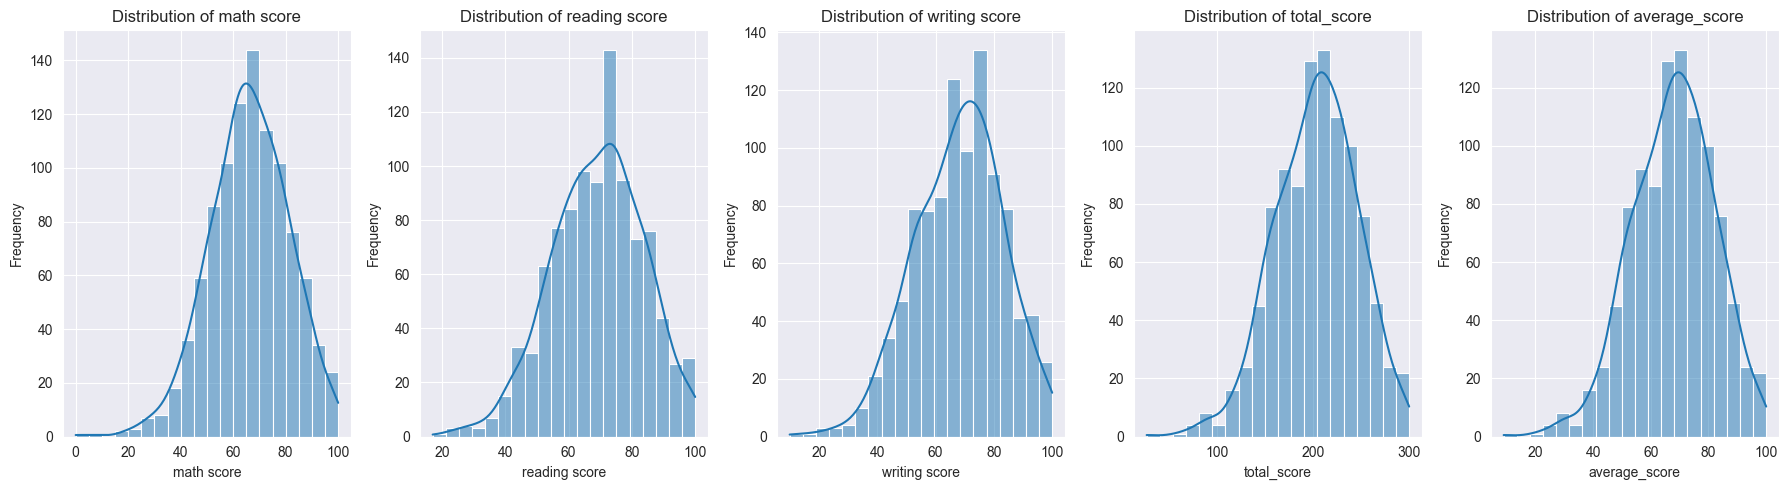

In [67]:
plt.figure(figsize=(18,5))

for i, col in enumerate(num_features, 1):
    plt.subplot(1, len(num_features), i)
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### INSIGHTS

From the above histogram we can infer these things:

1. All the numerical features are slightly left skewed
2. Math is the only subject where more students have scored less than 20 marks

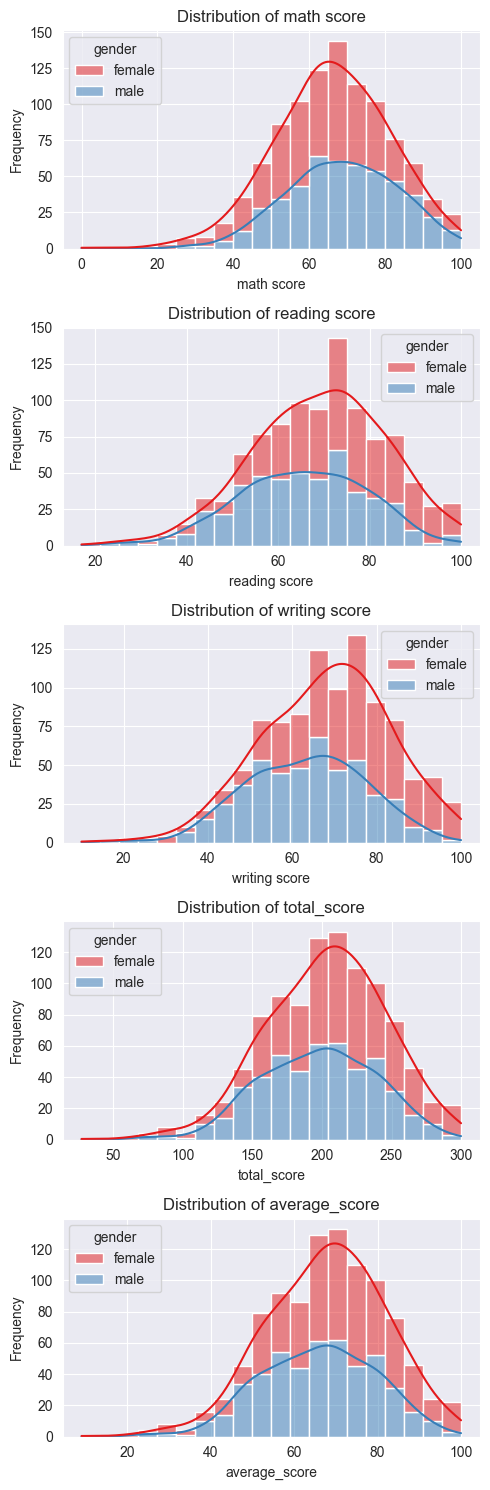

In [68]:
plt.figure(figsize=(5,15))

for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features),1, i)
    sns.histplot(data=df, x=col, bins=20, kde=True, hue='gender', palette='Set1', multiple='stack')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### INSIGHTS

From the above graphs we can infer that females have performed well in comparisons to males in almost all the subjects

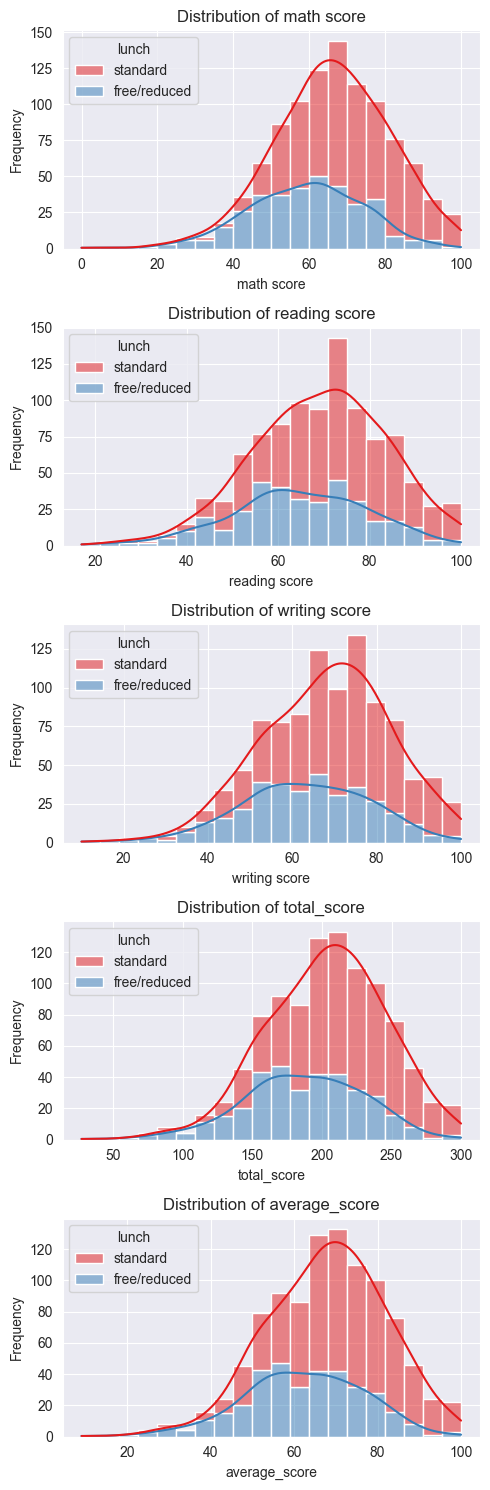

In [69]:
plt.figure(figsize=(5,15))

for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features),1, i)
    sns.histplot(data=df, x=col, bins=20, kde=True, hue='lunch', palette='Set1', multiple='stack')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### INSIGHTS

Students who have standard lunch perform well in comparison to the free/reduced lunch

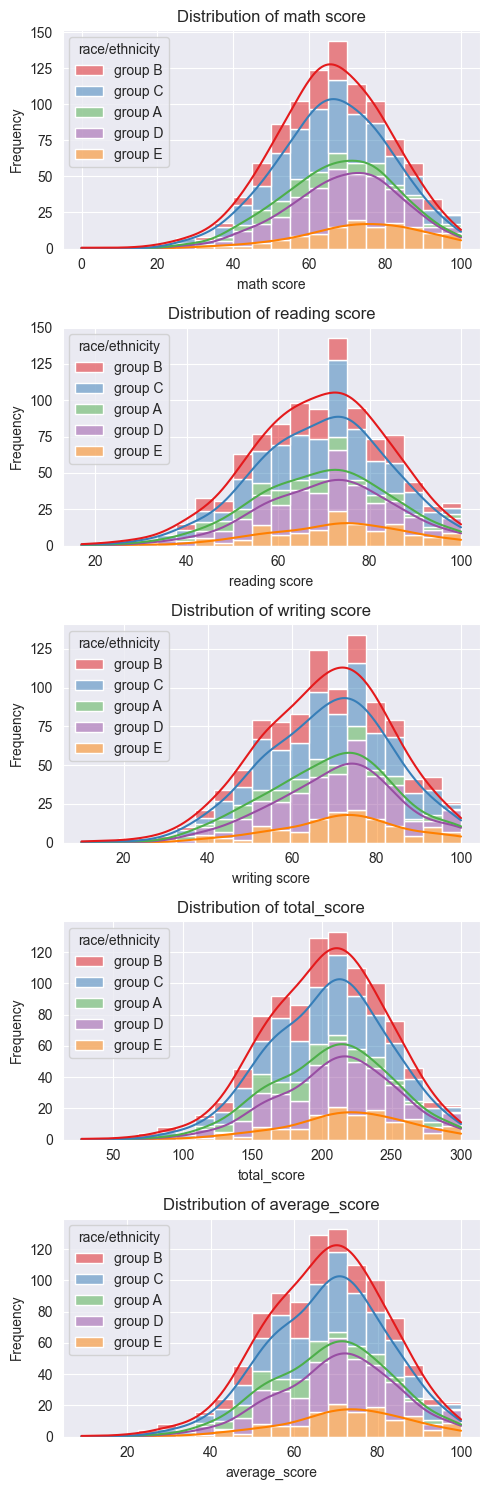

In [70]:
plt.figure(figsize=(5,15))

for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features),1, i)
    sns.histplot(data=df, x=col, bins=20, kde=True, hue='race/ethnicity', palette='Set1', multiple='stack')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

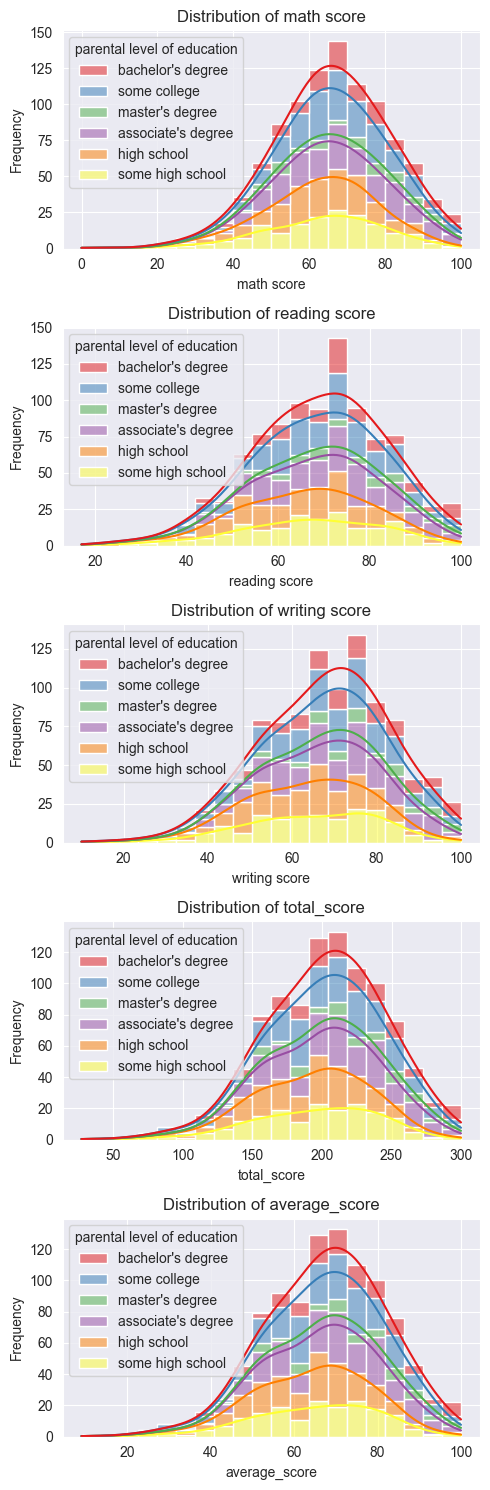

In [71]:
plt.figure(figsize=(5,15))

for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features),1, i)
    sns.histplot(data=df, x=col, bins=20, kde=True, hue='parental level of education', palette='Set1', multiple='stack')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

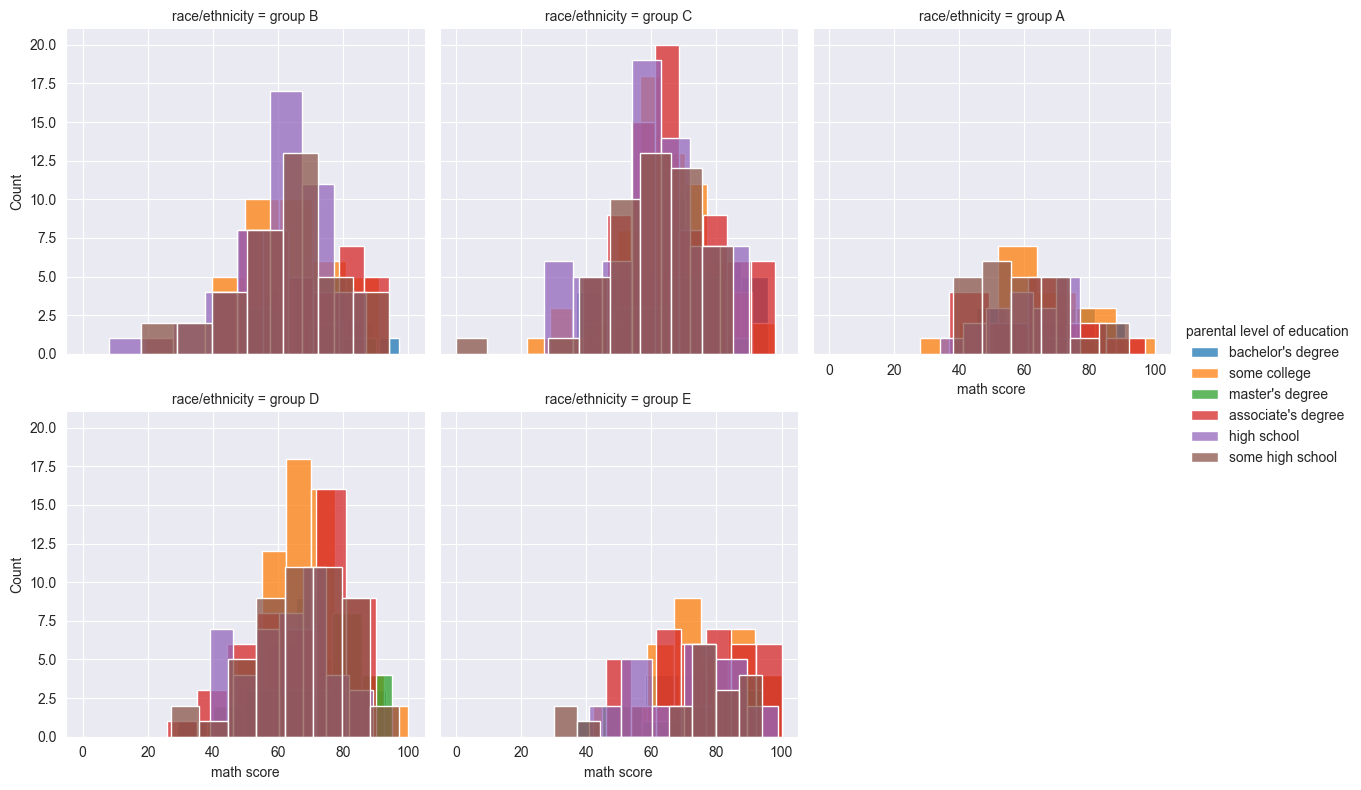

In [72]:
g = sns.FacetGrid(
    df,
    col="race/ethnicity",
    hue="parental level of education",
    col_wrap=3,
    height=4
)

g.map(sns.histplot, "math score")
g.add_legend()

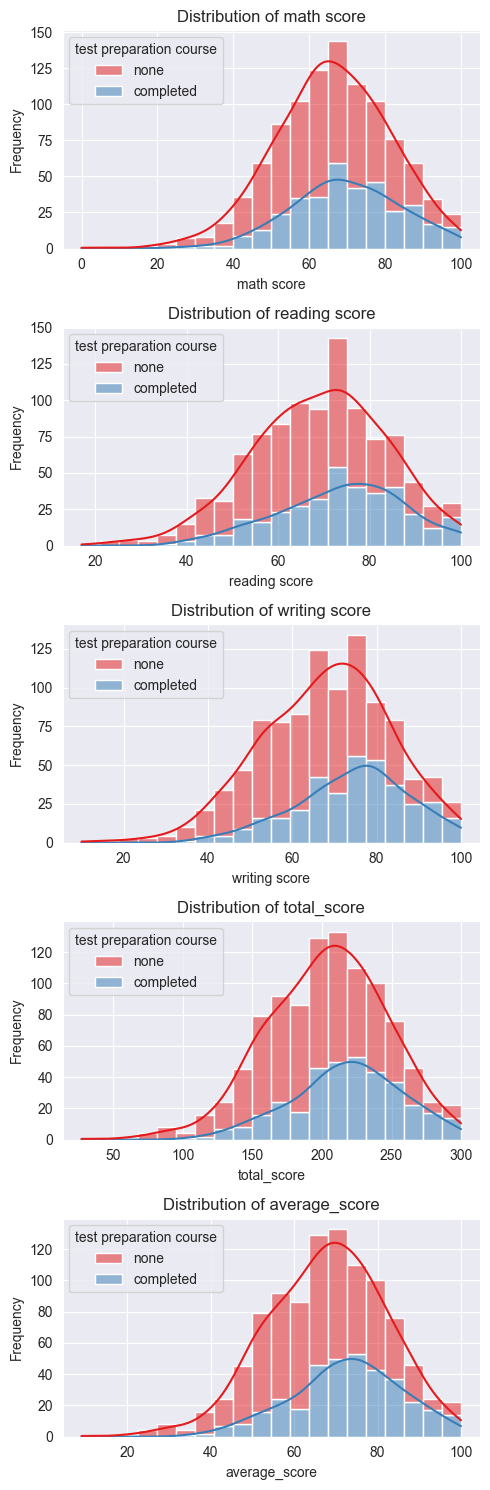

In [73]:
plt.figure(figsize=(5,15))

for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features),1, i)
    sns.histplot(data=df, x=col, bins=20, kde=True, hue='test preparation course', palette='Set1', multiple='stack')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

<Axes: xlabel='test preparation course', ylabel='math score'>

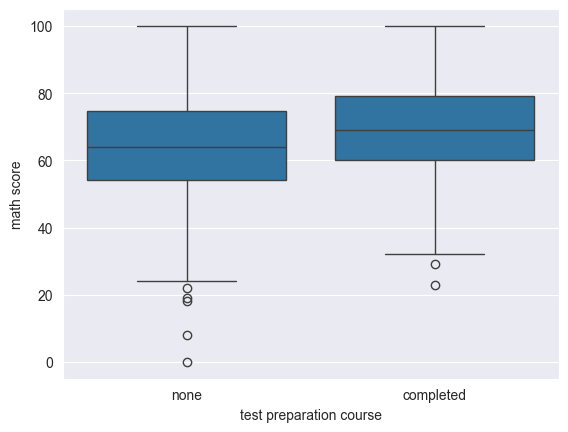

In [74]:
sns.boxplot(
    data=df,
    x="test preparation course",
    y="math score"
)

## FINAL CONLCUSION

1. Students performance is related with lunch, race/ethnicity, parental level of education
2. Females score better in reading and writing than males. Vice-versa for maths score
3. Students score doesnt depend much on test preparation course, but it is benefitial if they take one